# 03 – Feature Engineering
**AlchemiX – Launch26 Phase 2**

## Objectives
1. Load the three cleaned datasets
2. Create **safe** features only (no historical averages, no target leakage)
3. Derive the `trust_score` target for the Telemetry model
4. Save engineered datasets

## Allowed Features
- `planet_a`, `planet_b` (split from `link_id`)
- `load_percentage`, `load_bucket`, `near_capacity`, `high_congestion`
- `latency_difference`, `absolute_difference`, `latency_ratio`, `percentage_error`
- `trust_score` (derived target)
- `traffic_percentage`, `traffic_bucket`, `high_traffic_share`, `relative_traffic`
- Interaction and polynomial features

## Forbidden
- Historical averages / global means computed on all rows
- Historical attack rate, historical trust — these go in Notebook 04 after split
- Encoding or scaling
- Model training

In [1]:
import sys, pathlib
PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ml.utils import (
    TRAFFIC_CLEAN_FILE, TELEMETRY_CLEAN_FILE, INCIDENT_CLEAN_FILE,
    TRAFFIC_ENG_FILE, TELEMETRY_ENG_FILE, INCIDENT_ENG_FILE,
)
from ml.feature_engineering import (
    engineer_traffic_features,
    engineer_telemetry_features,
    engineer_incident_features,
)

print('Imports OK ✓')

Imports OK ✓


## 1. Load Cleaned Datasets

In [2]:
traffic_clean   = pd.read_csv(TRAFFIC_CLEAN_FILE)
telemetry_clean = pd.read_csv(TELEMETRY_CLEAN_FILE)
incident_clean  = pd.read_csv(INCIDENT_CLEAN_FILE)

print(f'Traffic   : {traffic_clean.shape}')
print(f'Telemetry : {telemetry_clean.shape}')
print(f'Incident  : {incident_clean.shape}')

Traffic   : (5743, 6)
Telemetry : (6000, 4)
Incident  : (6000, 4)


## 2. Traffic Feature Engineering

In [3]:
traffic_eng = engineer_traffic_features(traffic_clean)

print('New columns added:')
new_cols = [c for c in traffic_eng.columns if c not in traffic_clean.columns]
for c in new_cols:
    print(f'  {c}: {traffic_eng[c].dtype}  sample={traffic_eng[c].iloc[0]}')

display(traffic_eng[['link_id','planet_a','planet_b','load_ratio','load_bucket',
                      'near_capacity','high_congestion','load_ratio_sq','observed_latency_ms']].head(5))

03:19:39  INFO      ml.feature_engineering  split_link_id: added planet_a, planet_b columns
03:19:39  INFO      ml.feature_engineering  engineer_traffic_features: 15 features, 5743 rows


New columns added:
  planet_a: str  sample=Aegis
  planet_b: str  sample=Boreas
  load_percentage: float64  sample=43.28
  near_capacity: int64  sample=0
  high_congestion: int64  sample=0
  load_bucket: category  sample=medium
  status_ok: int64  sample=1
  load_ratio_sq: float64  sample=0.18731584
  load_units_x_ratio: float64  sample=38.952


,link_id,planet_a,planet_b,load_ratio,load_bucket,near_capacity,high_congestion,load_ratio_sq,observed_latency_ms
0,Aegis-Boreas,Aegis,Boreas,0.4328,medium,0,0,0.187316,118635.583
1,Aegis-Boreas,Aegis,Boreas,0.6557,high,0,0,0.429942,283818.179
2,Aegis-Boreas,Aegis,Boreas,0.2681,low,0,0,0.071878,76938.079
3,Aegis-Boreas,Aegis,Boreas,0.0692,very_low,0,0,0.004789,61680.208
4,Aegis-Boreas,Aegis,Boreas,0.7293,high,0,0,0.531878,413268.959


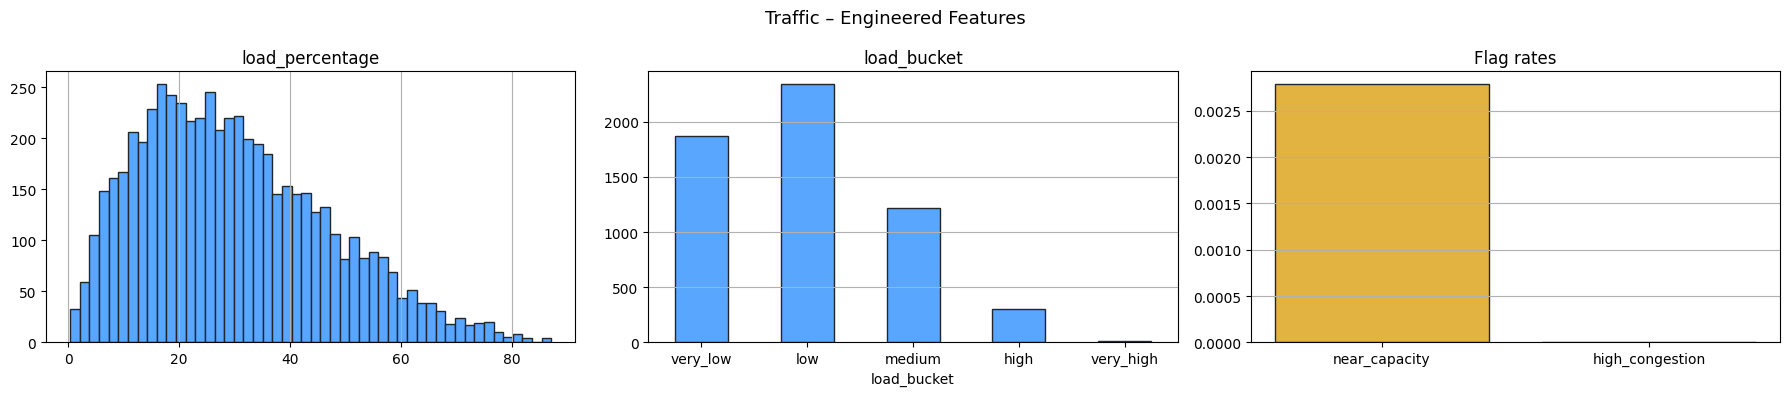

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Traffic – Engineered Features', fontsize=13)

traffic_eng['load_percentage'].hist(bins=50, ax=axes[0], color='#58a6ff', edgecolor='#21262d')
axes[0].set_title('load_percentage'); axes[0].grid(axis='y')

traffic_eng['load_bucket'].value_counts().sort_index().plot.bar(
    ax=axes[1], color='#58a6ff', edgecolor='#21262d', rot=0
)
axes[1].set_title('load_bucket'); axes[1].grid(axis='y')

axes[2].bar(['near_capacity','high_congestion'],
             [traffic_eng['near_capacity'].mean(), traffic_eng['high_congestion'].mean()],
             color=['#e3b341','#f85149'], edgecolor='#21262d')
axes[2].set_title('Flag rates'); axes[2].grid(axis='y')
plt.tight_layout(); plt.show()

## 3. Telemetry Feature Engineering & Trust Score

In [5]:
telemetry_eng = engineer_telemetry_features(telemetry_clean)

print('New columns:')
new_cols = [c for c in telemetry_eng.columns if c not in telemetry_clean.columns]
for c in new_cols:
    print(f'  {c}: dtype={telemetry_eng[c].dtype}')

display(telemetry_eng[['link_id','tick','self_reported_latency_ms','measured_latency_ms',
                         'latency_difference','trust_score']].head(5))

03:19:40  INFO      ml.feature_engineering  split_link_id: added planet_a, planet_b columns
03:19:40  INFO      ml.feature_engineering  engineer_telemetry_features: 11 features, 6000 rows


New columns:
  planet_a: dtype=str
  planet_b: dtype=str
  latency_difference: dtype=float64
  absolute_difference: dtype=float64
  latency_ratio: dtype=float64
  percentage_error: dtype=float64
  trust_score: dtype=float64


,link_id,tick,self_reported_latency_ms,measured_latency_ms,latency_difference,trust_score
0,Aegis-Boreas,0,69804.794,70246.059,441.265,0.9938
1,Aegis-Boreas,1,438998.039,461750.906,22752.867,0.9530
2,Aegis-Boreas,2,69595.273,71962.130,2366.857,0.9682
3,Aegis-Boreas,3,70575.341,74284.268,3708.927,0.9524
4,Aegis-Boreas,4,78208.292,81932.917,3724.625,0.9565


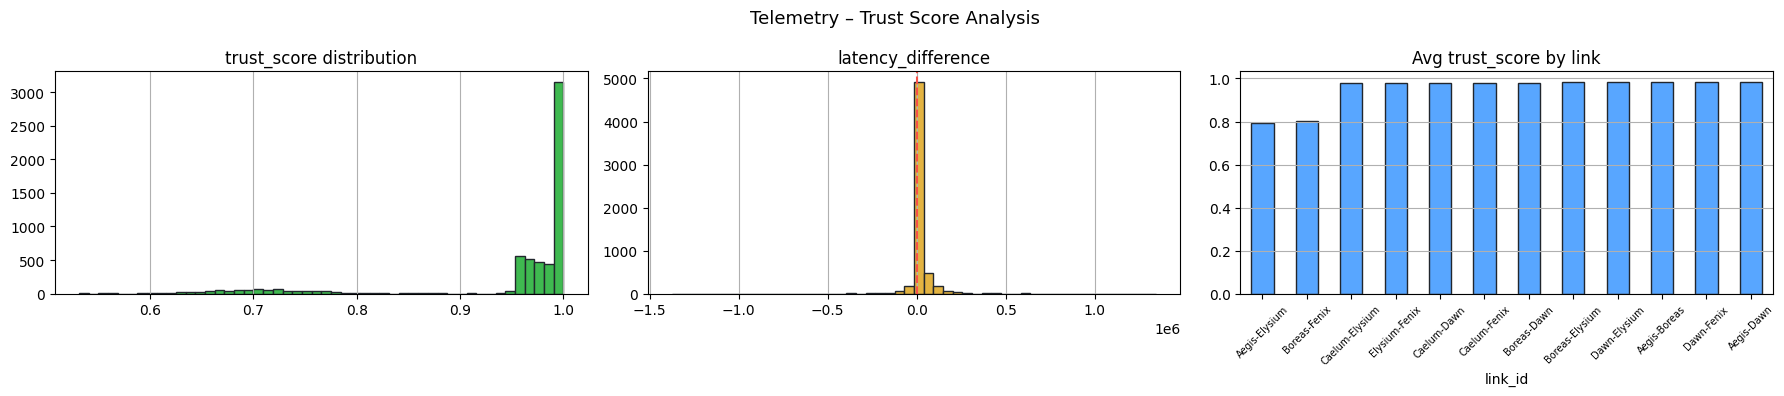

Trust score range: 0.5315 – 1.0000
Mean trust score : 0.9506


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Telemetry – Trust Score Analysis', fontsize=13)

telemetry_eng['trust_score'].hist(bins=50, ax=axes[0], color='#3fb950', edgecolor='#21262d')
axes[0].set_title('trust_score distribution'); axes[0].grid(axis='y')

telemetry_eng['latency_difference'].hist(bins=50, ax=axes[1], color='#e3b341', edgecolor='#21262d')
axes[1].axvline(0, color='#f85149', linestyle='--')
axes[1].set_title('latency_difference'); axes[1].grid(axis='y')

# Average trust per link
trust_by_link = telemetry_eng.groupby('link_id')['trust_score'].mean().sort_values()
trust_by_link.plot.bar(ax=axes[2], color='#58a6ff', edgecolor='#21262d', rot=45)
axes[2].set_title('Avg trust_score by link'); axes[2].grid(axis='y')
axes[2].tick_params(axis='x', labelsize=7)
plt.tight_layout(); plt.show()

print(f'Trust score range: {telemetry_eng["trust_score"].min():.4f} – {telemetry_eng["trust_score"].max():.4f}')
print(f'Mean trust score : {telemetry_eng["trust_score"].mean():.4f}')

## 4. Incident Feature Engineering

In [7]:
incident_eng = engineer_incident_features(incident_clean)

print('New columns:')
new_cols = [c for c in incident_eng.columns if c not in incident_clean.columns]
for c in new_cols:
    print(f'  {c}: dtype={incident_eng[c].dtype}')

display(incident_eng[['link_id','tick','traffic_share','traffic_percentage',
                        'traffic_bucket','high_traffic_share','jammed_flag']].head(5))

03:19:40  INFO      ml.feature_engineering  split_link_id: added planet_a, planet_b columns
03:19:40  INFO      ml.feature_engineering  engineer_incident_features: 11 features, 6000 rows


New columns:
  planet_a: dtype=str
  planet_b: dtype=str
  traffic_percentage: dtype=float64
  traffic_bucket: dtype=category
  high_traffic_share: dtype=int64
  relative_traffic: dtype=float64
  jammed_int: dtype=int64


,link_id,tick,traffic_share,traffic_percentage,traffic_bucket,high_traffic_share,jammed_flag
0,Aegis-Boreas,0,0.03833,3.83,very_low,0,False
1,Aegis-Dawn,0,0.05373,5.37,low,0,False
2,Aegis-Elysium,0,0.06344,6.34,low,0,True
3,Boreas-Dawn,0,0.12564,12.56,medium,0,False
4,Boreas-Elysium,0,0.00766,0.77,very_low,0,False


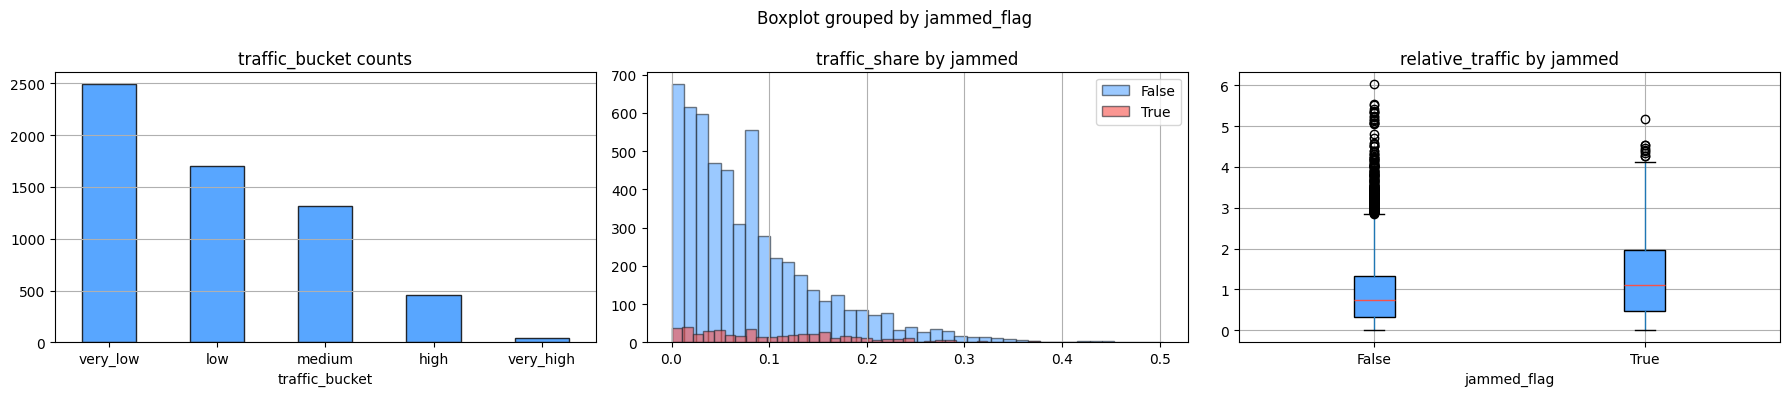

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Incident – Engineered Features', fontsize=13)

incident_eng['traffic_bucket'].value_counts().sort_index().plot.bar(
    ax=axes[0], color='#58a6ff', edgecolor='#21262d', rot=0
)
axes[0].set_title('traffic_bucket counts'); axes[0].grid(axis='y')

# traffic_share vs jammed
for label, grp in incident_eng.groupby('jammed_flag'):
    grp['traffic_share'].hist(bins=40, ax=axes[1], alpha=0.6,
                              label=str(label),
                              color='#58a6ff' if not label else '#f85149',
                              edgecolor='#21262d')
axes[1].legend(); axes[1].set_title('traffic_share by jammed'); axes[1].grid(axis='y')

# relative_traffic vs jammed
incident_eng.boxplot(column='relative_traffic', by='jammed_flag', ax=axes[2],
                     patch_artist=True,
                     boxprops=dict(facecolor='#58a6ff'),
                     medianprops=dict(color='#f85149'))
axes[2].set_title('relative_traffic by jammed'); axes[2].grid(True)
plt.tight_layout(); plt.show()

## 5. Save Engineered Datasets

In [9]:
traffic_eng.to_csv(TRAFFIC_ENG_FILE,   index=False)
telemetry_eng.to_csv(TELEMETRY_ENG_FILE, index=False)
incident_eng.to_csv(INCIDENT_ENG_FILE,  index=False)

print('Saved:')
print(f'  {TRAFFIC_ENG_FILE}    ({len(traffic_eng)} rows, {len(traffic_eng.columns)} cols)')
print(f'  {TELEMETRY_ENG_FILE}  ({len(telemetry_eng)} rows, {len(telemetry_eng.columns)} cols)')
print(f'  {INCIDENT_ENG_FILE}   ({len(incident_eng)} rows, {len(incident_eng.columns)} cols)')
print('\n✓ Notebook 03 complete – proceed to Notebook 04 Model Training.')

Saved:
  E:\AlchemiX\datasets\engineered\traffic_engineered.csv    (5743 rows, 15 cols)
  E:\AlchemiX\datasets\engineered\telemetry_engineered.csv  (6000 rows, 11 cols)
  E:\AlchemiX\datasets\engineered\incident_engineered.csv   (6000 rows, 11 cols)

✓ Notebook 03 complete – proceed to Notebook 04 Model Training.
